In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Kernel, RBF, WhiteKernel, Matern, ConstantKernel as C
from sklearn.gaussian_process.kernels import Hyperparameter

import jax.numpy as jnp

from jax import random
from jax.example_libraries import optimizers
from jax import jit, grad, vmap
from jax import tree_util as jtu

import functools

import neural_tangents as nt
from neural_tangents import stax

import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from contextlib import contextmanager


In [2]:
#Plot settings
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('pdf', 'svg')
import matplotlib
import seaborn as sns

sns.set(font_scale=1.3)
sns.set_style("darkgrid", {"axes.facecolor": ".95"})

import matplotlib.pyplot as plt

def format_plot(x=None, y=None):
  # plt.grid(False)
  ax = plt.gca()
  if x is not None:
    plt.xlabel(x, fontsize=20)
  if y is not None:
    plt.ylabel(y, fontsize=20)

def finalize_plot(shape=(1, 1)):
  plt.gcf().set_size_inches(
    shape[0] * 1.5 * plt.gcf().get_size_inches()[1],
    shape[1] * 1.5 * plt.gcf().get_size_inches()[1])
  plt.tight_layout()

legend = functools.partial(plt.legend, fontsize=10)

def plot_fn(train, test, *fs):
  train_xs, train_ys = train

  plt.plot(train_xs, train_ys, 'ro', markersize=10, label='train')

  if test != None:
    test_xs, test_ys = test
    plt.plot(test_xs, test_ys, 'k--', linewidth=3, label='$f(x)$')

    for f in fs:
      plt.plot(test_xs, f(test_xs), '-', linewidth=3)

  plt.xlim([-jnp.pi, jnp.pi])
  # plt.ylim([-1.5, 1.5])

  format_plot('$x$', '$f(x)$')

/var/folders/ld/k3z4_g8n0nvdb_19cpz6t30h0000gn/T/ipykernel_12919/3367370499.py:3: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('pdf', 'svg')


In [3]:
def loss_fn(predict_fn, ys, t, xs=None):
  mean, cov = predict_fn(t=t, get='ntk', x_test=xs, compute_cov=True)
  mean = jnp.reshape(mean, mean.shape[:1] + (-1,))
  var = jnp.diagonal(cov, axis1=1, axis2=2)
  ys = jnp.reshape(ys, (1, -1))

  mean_predictions = 0.5 * jnp.mean(ys ** 2 - 2 * mean * ys + var + mean ** 2,
                                   axis=1)

  return mean_predictions

## Create data set for all approaches

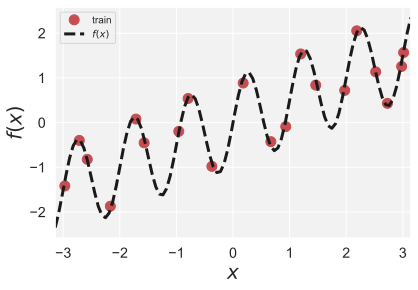

In [4]:
key = random.PRNGKey(42)

train_points = 20
test_points = 100
noise_scale = 1e-1

target_fn = lambda x: jnp.sin(2 * jnp.pi * x) +0.5*x

# Generating training data set
# randomly choosen x and noise
# generate random inputs, apply target function and add random noise
key, x_key, y_key = random.split(key, 3)

train_xs = random.uniform(x_key, (train_points, 1), minval=-jnp.pi, maxval=jnp.pi)

train_ys = target_fn(train_xs)
train_ys += noise_scale * random.normal(y_key, (train_points, 1))
train = (train_xs, train_ys)
# print(train)

# Generate test data with shape (N,1)
# treat it as model with one input feature
# extendable to higher dimensions
test_xs = jnp.linspace(-jnp.pi, jnp.pi, test_points)
test_xs = jnp.reshape(test_xs, (test_points, 1))

test_ys = target_fn(test_xs)
test = (test_xs, test_ys)
# print(test)

# Look at train data
plot_fn(train, test)
legend(loc='upper left')
finalize_plot((0.85, 0.6))

## Gaussian Process for different kernels

### RBF kernel

Notes:
Build an ensemble for RBF kernel to determine syst and stat
Assuming the internal unc are syst? read on that 

In [96]:
X_train = np.array(train_xs)
y_train = np.array(train_ys).ravel()

kernel = C(1.25, (1.1, 1.4)) * RBF(0.31, (0.29, 0.35)) 
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=50,
    alpha=noise_scale**2,
    normalize_y=False
)
gp.fit(X_train, y_train)

# Predict on test grid
X_test_np = np.array(test_xs)
mean_np, std_np = gp.predict(X_test_np, return_std=True)
mean_np = mean_np.reshape(-1, 1)
mean_1d, std_1d = gp.predict(X_test_np, return_std=True)

gp.kernel_

/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1.4. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.29. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


1.18**2 * RBF(length_scale=0.29)

In [97]:
def gp_mean_fn(x):
  x_np = np.array(x)
  mean = gp.predict(x_np, return_std=False)
  return jnp.array(mean).reshape(x.shape[0], 1)

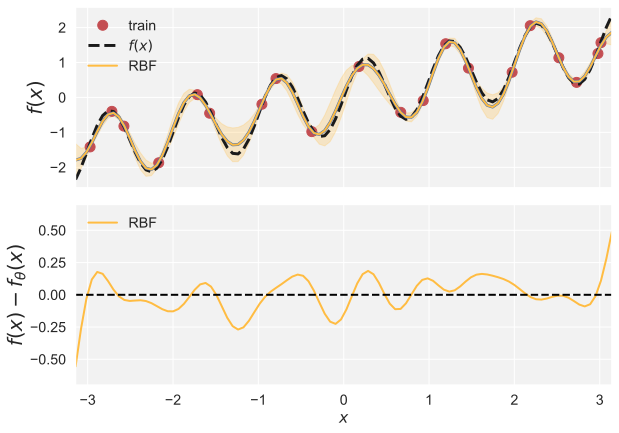

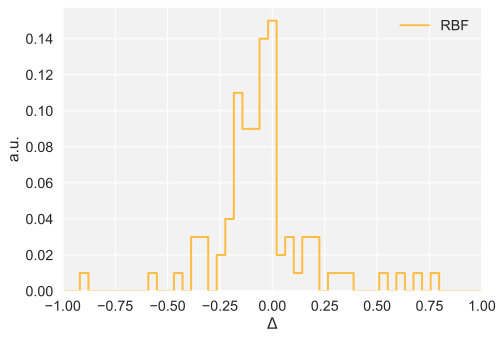

In [98]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True
)

plt.sca(ax_top)
plot_fn(train, test, gp_mean_fn)

plt.plot(test_xs, gp_mean_fn(test_xs), '-', linewidth=2, color='#ffbc42', label='RBF')

lo = (mean_1d - std_1d).ravel()
hi = (mean_1d + std_1d).ravel()
plt.fill_between(X_test_np.ravel(), lo, hi, alpha=0.25, color='#ffbc42')

plt.xlim([-jnp.pi, jnp.pi])
plt.legend(loc='upper left', frameon=False)
plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_rbf = np.array(test_ys).ravel() - gp_mean_fn(test_xs).ravel()

plt.plot(test_xs, residuals_rbf, '#ffbc42', linewidth=2, label='RBF')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_\theta(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False)
plt.ylim([-0.7, 0.7])

plt.tight_layout()
plt.savefig("figs/RBF_kernel.pdf")
plt.show()
plt.close()

delta_rbf= (gp_mean_fn(test_xs).ravel() - np.array(test_ys).ravel())/np.array(test_ys).ravel()
dup = lambda a: np.append(a, a[-1])
fig, axs = plt.subplots( 1, 1, figsize=(7,5))
fig.tight_layout(pad=0.0, w_pad=0.0, h_pad=0.0, rect=(0.08, 0.08, 0.99, 0.95))
hist1, bins = np.histogram(delta_rbf.flatten(), bins=np.linspace(-1, 1, 50))
hist1 = hist1/ len(delta_rbf)
axs.step(bins, dup(hist1), color='#ffbc42', linestyle='solid', label='RBF', where='post', linewidth=2)
axs.set_xlabel('$\\Delta$')
axs.set_xlim([-1, 1])
axs.set_ylim(0.0)
axs.set_ylabel('a.u.')
axs.legend(frameon=False, loc='upper right')
plt.show()
plt.close()


### Gibbs kernel

In [76]:
import numpy as np
from sklearn.gaussian_process.kernels import Kernel, Hyperparameter


class GibbsKernel1D(Kernel):
    """
    1D Gibbs kernel with linear lengthscale:
        l(x) = l0 * (x + delta)

    delta is FIXED.
    Trainable hyperparameters:
        theta = [log_l0, log_sigma2]
    """

    def __init__(
        self,
        l0=1.0, delta=0.0, sigma2=1.0,
        l0_bounds=(1e-6, 1e6),
        sigma2_bounds=(1e-6, 1e6),
    ):
        self.l0 = float(l0)
        self.delta = float(delta)   # fixed
        self.sigma2 = float(sigma2)

        self.l0_bounds = l0_bounds
        self.sigma2_bounds = sigma2_bounds

    # --- sklearn hyperparameter metadata (only for l0, sigma2)
    @property
    def hyperparameter_l0(self):
        return Hyperparameter("l0", "numeric", self.l0_bounds)

    @property
    def hyperparameter_sigma2(self):
        return Hyperparameter("sigma2", "numeric", self.sigma2_bounds)

    # --- trainable vector (2 params)
    @property
    def theta(self):
        return np.array([np.log(self.l0), np.log(self.sigma2)])

    @theta.setter
    def theta(self, theta):
        self.l0 = float(np.exp(theta[0]))
        self.sigma2 = float(np.exp(theta[1]))
        # delta unchanged

    @property
    def bounds(self):
        return np.array([
            np.log(self.l0_bounds),
            np.log(self.sigma2_bounds),
        ])

    # --- lengthscale
    def _ell(self, X):
        x = X[:, 0]
        ell = self.l0 * (np.abs(x) + self.delta)
        # keep valid during optimization
        if np.any(ell <= 0):
            ell = np.maximum(ell, 1e-12)
        return ell

    def __call__(self, X, Y=None, eval_gradient=False):
        X = np.atleast_2d(X)
        if X.shape[1] != 1:
            raise ValueError("GibbsKernel1D only supports 1D inputs (n,1).")

        Y = X if Y is None else np.atleast_2d(Y)
        if Y.shape[1] != 1:
            raise ValueError("GibbsKernel1D only supports 1D inputs (m,1).")

        x = X[:, 0][:, None]
        y = Y[:, 0][None, :]

        ell_x = self._ell(X)[:, None]
        ell_y = self._ell(Y)[None, :]

        denom = ell_x**2 + ell_y**2
        diff2 = (x - y) ** 2

        pref = np.sqrt(4.0 * ell_x * ell_y / denom)
        expo = np.exp(-diff2 / denom)

        K = self.sigma2 * pref * expo
        print(self.l0, self.delta, self.sigma2)

        if not eval_gradient:
            return K

        # ---- gradients wrt theta = [log_l0, log_sigma2]

        # l(x) = l0*(x+delta)  => d l / d log_l0 = l
        d_ellx_dlogl0 = ell_x
        d_elly_dlogl0 = ell_y

        def dlogK(d_ellx, d_elly):
            d_denom = 2*ell_x*d_ellx + 2*ell_y*d_elly
            term_pref = 0.5 * (d_ellx/ell_x + d_elly/ell_y - d_denom/denom)
            term_exp  = diff2 * d_denom / (denom**2)
            return term_pref + term_exp

        dlogK_dlogl0 = dlogK(d_ellx_dlogl0, d_elly_dlogl0)

        dK_dlogl0     = K * dlogK_dlogl0
        dK_dlogsigma2 = K

        grad = np.stack([dK_dlogl0, dK_dlogsigma2], axis=2)
        return K, grad

    def diag(self, X):
        return np.full(np.atleast_2d(X).shape[0], self.sigma2)

    def is_stationary(self):
        return False


def gp_mean_gibbs_fn(x): 
    x_np = np.array(x) 
    mean = gp_gibbs.predict(x_np, return_std=False) 
    return jnp.array(mean).reshape(x.shape[0], 1)


In [94]:
X_train = np.array(train_xs).reshape(-1, 1)
y_train = np.array(train_ys).ravel()
X_test  = np.array(test_xs).reshape(-1, 1)

kernel = GibbsKernel1D(
    
    l0=0.1,
    delta=2*np.pi,
    sigma2=0.1,
    l0_bounds=(0.05, 0.5),
    sigma2_bounds=(0.5, 2)
)

gp_gibbs = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=50,  # now meaningful
    alpha=1e-3,
    normalize_y=True,
    random_state=0
)

gp_gibbs.fit(X_train, y_train)

print(gp_gibbs.kernel_)

# Predict on test grid
X_test_np = np.array(test_xs)
# X_test_s  = scaler.transform(X_test_np)
mean_gibbs, std_gibbs = gp_gibbs.predict(X_test_np, return_std=True)
mean_gibbs = mean_gibbs.reshape(-1, 1)
mean_1d_gibbs, std_1d_gibbs = gp_gibbs.predict(X_test_np, return_std=True)


0.10000000000000002 6.283185307179586 0.5
0.05000000000000001 6.283185307179586 2.0
0.17692267954532756 6.283185307179586 1.3475872957290465
0.05000000000000001 6.283185307179586 2.0
0.20032418309821973 6.283185307179586 1.0641978293721805
0.05000000000000001 6.283185307179586 2.0
0.13262481883797375 6.283185307179586 1.2241566846896814
0.05000000000000001 6.283185307179586 2.0
0.13694847976173485 6.283185307179586 1.7213566016258586
0.05000000000000001 6.283185307179586 2.0
0.4598675496284058 6.283185307179586 0.8507947509745648
0.05000000000000001 6.283185307179586 2.0
0.30952450833870915 6.283185307179586 1.040869960870501
0.05000000000000001 6.283185307179586 2.0
0.18493306410514398 6.283185307179586 1.803992419853749
0.05000000000000001 6.283185307179586 2.0
0.05888518753760857 6.283185307179586 0.564192189674845
0.05000000000000001 6.283185307179586 2.0
0.05238276295543258 6.283185307179586 1.5858317233321109
0.05000000000000001 6.283185307179586 2.0
0.30000379968058766 6.2831853

/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter l0 is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter sigma2 is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(
/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(


0.05000000000000001 6.283185307179586 2.0
0.05000000000000001 6.283185307179586 2.0
0.05000000000000001 6.283185307179586 2.0


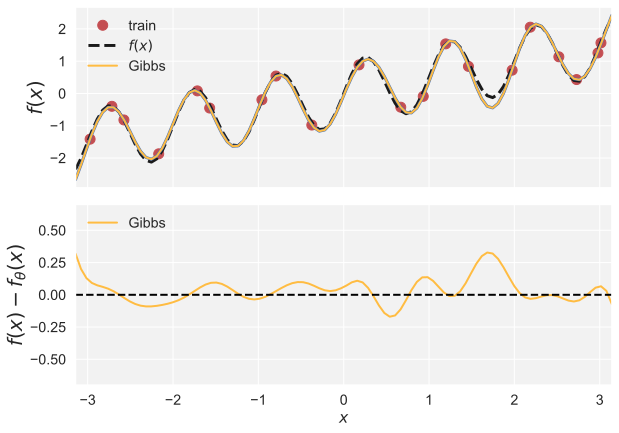

0.05000000000000001 6.283185307179586 2.0


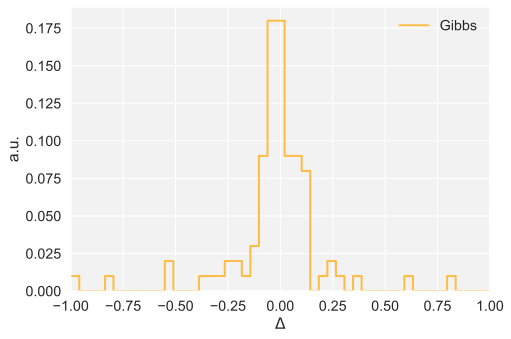

In [95]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True
)

plt.sca(ax_top)
plot_fn(train, test, gp_mean_gibbs_fn)

plt.plot(test_xs, gp_mean_gibbs_fn(test_xs), '-', linewidth=2, color='#ffbc42', label='Gibbs')

lo_gibbs = (mean_1d_gibbs - std_1d_gibbs).ravel()
hi_gibbs = (mean_1d_gibbs + std_1d_gibbs).ravel()
plt.fill_between(X_test_np.ravel(), lo_gibbs, hi_gibbs, alpha=0.25, color='#ffbc42')

plt.xlim([-jnp.pi, jnp.pi])
plt.legend(loc='upper left', frameon=False)
plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_gibbs = np.array(test_ys).ravel() - gp_mean_gibbs_fn(test_xs).ravel()

plt.plot(test_xs, residuals_gibbs, '#ffbc42', linewidth=2, label='Gibbs')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_\theta(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False)
plt.ylim([-0.7, 0.7])

plt.tight_layout()
# plt.savefig("figs/RBF_kernel.pdf")
plt.show()
plt.close()

delta_gibbs = (gp_mean_gibbs_fn(test_xs).ravel() - np.array(test_ys).ravel())/np.array(test_ys).ravel()
dup = lambda a: np.append(a, a[-1])
fig, axs = plt.subplots( 1, 1, figsize=(7,5))
fig.tight_layout(pad=0.0, w_pad=0.0, h_pad=0.0, rect=(0.08, 0.08, 0.99, 0.95))
hist1, bins = np.histogram(delta_gibbs.flatten(), bins=np.linspace(-1, 1, 50))
hist1 = hist1/ len(delta_gibbs)
axs.step(bins, dup(hist1), color='#ffbc42', linestyle='solid', label='Gibbs', where='post', linewidth=2)
axs.set_xlabel('$\\Delta$')
axs.set_xlim([-1, 1])
axs.set_ylim(0.0)
axs.set_ylabel('a.u.')
axs.legend(frameon=False, loc='upper right')
plt.show()
plt.close()


### Matern kernel

In [99]:
def gp_mean_matern_fn(x):
  x_np = np.array(x)
  mean = gp_matern.predict(x_np, return_std=False)
  return jnp.array(mean).reshape(x.shape[0], 1)

In [100]:
X_train = np.array(train_xs)
y_train = np.array(train_ys).ravel()

kernel_matern = C(1.25, (1.0, 1.4)) * Matern(
    length_scale=1.0,
    length_scale_bounds=(0.8, 1.2),
    nu=2.5  # 0.5=rough, 1.5=moderate, 2.5=smoother, inf -> RBF
)

gp_matern = GaussianProcessRegressor(
    kernel=kernel_matern,
    n_restarts_optimizer=50,
    normalize_y=True,
    random_state=0,
    alpha=1e-8
)
gp_matern.fit(X_train, y_train)

print(gp_matern.kernel_)

# Predict on test grid
X_test_np = np.array(test_xs)
# X_test_s  = scaler.transform(X_test_np)
mean_matern, std_matern = gp_matern.predict(X_test_np, return_std=True)
mean_matern = mean_matern.reshape(-1, 1)
mean_1d_matern, std_1d_matern = gp_matern.predict(X_test_np, return_std=True)


1.18**2 * Matern(length_scale=0.8, nu=2.5)


/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1.4. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.8. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


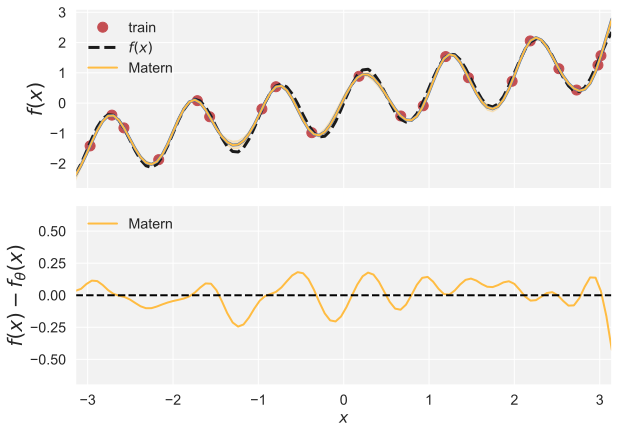

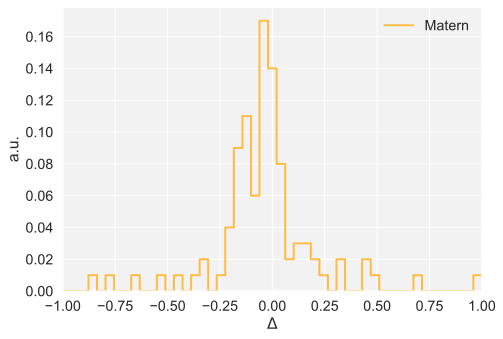

In [101]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True
)

plt.sca(ax_top)
plot_fn(train, test, gp_mean_matern_fn)

plt.plot(test_xs, gp_mean_matern_fn(test_xs), '-', linewidth=2, color='#ffbc42', label='Matern')

lo_matern = (mean_1d_matern - std_1d_matern).ravel()
hi_matern = (mean_1d_matern + std_1d_matern).ravel()
plt.fill_between(X_test_np.ravel(), lo_matern, hi_matern, alpha=0.25, color='#ffbc42')

plt.xlim([-jnp.pi, jnp.pi])
plt.legend(loc='upper left', frameon=False)
plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_matern = np.array(test_ys).ravel() - gp_mean_matern_fn(test_xs).ravel()
plt.plot(test_xs, residuals_matern, '#ffbc42', linewidth=2, label='Matern')
plt.axhline(0, linestyle='--', color='black', linewidth=2)
plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_\theta(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False)
plt.ylim([-0.7, 0.7])

plt.tight_layout()
# plt.savefig("figs/RBF_kernel.pdf")
plt.show()
plt.close()

delta_matern = (gp_mean_matern_fn(test_xs).ravel() - np.array(test_ys).ravel())/np.array(test_ys).ravel()
dup = lambda a: np.append(a, a[-1])
fig, axs = plt.subplots( 1, 1, figsize=(7,5))
fig.tight_layout(pad=0.0, w_pad=0.0, h_pad=0.0, rect=(0.08, 0.08, 0.99, 0.95))
hist1, bins = np.histogram(delta_matern.flatten(), bins=np.linspace(-1, 1, 50))
hist1 = hist1/ len(delta_matern)
axs.step(bins, dup(hist1), color='#ffbc42', linestyle='solid', label='Matern', where='post', linewidth=2)
axs.set_xlabel('$\\Delta$')
axs.set_xlim([-1, 1])
axs.set_ylim(0.0)
axs.set_ylabel('a.u.')
axs.legend(frameon=False, loc='upper right')
plt.show()
plt.close()


### all kernel in one plot

0.05000000000000001 6.283185307179586 2.0


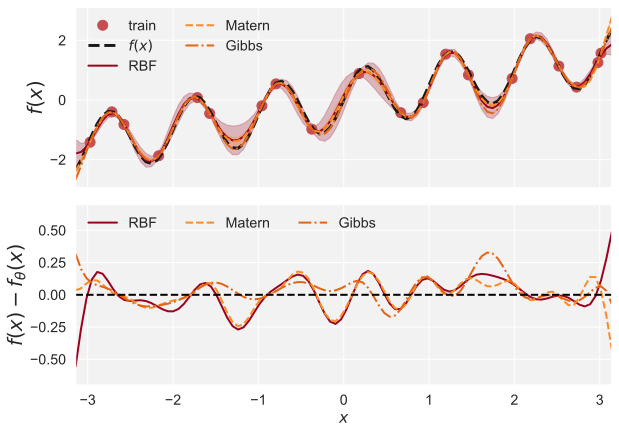

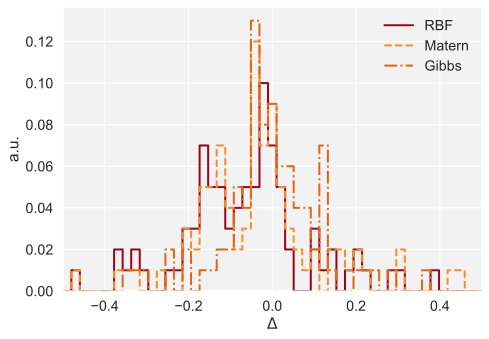

In [111]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True
)

plt.sca(ax_top)
plot_fn(train, test)

plt.plot(test_xs, gp_mean_fn(test_xs), '-', linewidth=2, color='#9A031E', label='RBF')
plt.plot(test_xs, gp_mean_matern_fn(test_xs), '--', linewidth=2, color='#FB8B24', label='Matern')
plt.plot(test_xs, gp_mean_gibbs_fn(test_xs), '-.', linewidth=2, color='#E36414', label='Gibbs')

plt.fill_between(X_test_np.ravel(), lo, hi, alpha=0.25, color='#9A031E')
plt.fill_between(X_test_np.ravel(), lo_matern, hi_matern, alpha=0.25, color='#FB8B24')
plt.fill_between(X_test_np.ravel(), lo_gibbs, hi_gibbs, alpha=0.25, color='#E36414')

plt.xlim([-jnp.pi, jnp.pi])
plt.legend(loc='upper left', frameon=False, ncol=2)
plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)
plt.plot(test_xs, residuals_rbf, '-', color='#9A031E', linewidth=2, label='RBF')
plt.plot(test_xs, residuals_matern, '--', color='#FB8B24', linewidth=2, label='Matern')
plt.plot(test_xs, residuals_gibbs, '-.', color='#E36414', linewidth=2, label='Gibbs')
plt.axhline(0, linestyle='--', color='black', linewidth=2)
plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_\theta(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False, ncol=3)
plt.ylim([-0.7, 0.7])
plt.tight_layout()
plt.savefig("figs/kernel_tests.pdf")
plt.show()
plt.close()

dup = lambda a: np.append(a, a[-1])
fig, axs = plt.subplots( 1, 1, figsize=(7,5))
fig.tight_layout(pad=0.0, w_pad=0.0, h_pad=0.0, rect=(0.08, 0.08, 0.99, 0.95))
hist1, bins = np.histogram(delta_rbf.flatten(), bins=np.linspace(-0.5, 0.5, 50))
hist1 = hist1/ len(delta_rbf)
hist2, bins = np.histogram(delta_matern.flatten(), bins=np.linspace(-0.5, 0.5, 50))
hist2 = hist2/ len(delta_matern)
hist3, bins = np.histogram(delta_gibbs.flatten(), bins=np.linspace(-0.5, 0.5, 50))
hist3 = hist3/ len(delta_gibbs)
axs.step(bins, dup(hist1), color='#9A031E', linestyle='solid', label='RBF', where='post', linewidth=2)
axs.step(bins, dup(hist2), color='#FB8B24', linestyle='dashed', label='Matern', where='post', linewidth=2)
axs.step(bins, dup(hist3), color='#E36414', linestyle='dashdot', label='Gibbs', where='post', linewidth=2)
axs.set_xlabel('$\\Delta$')
axs.set_xlim([-0.5, 0.5])
axs.set_ylim(0.0)
axs.set_ylabel('a.u.')
axs.legend(frameon=False, loc='upper right')
plt.show()
plt.close()


## NTK kernel

Implementation from cookbook

### Define Neural Network

- fully connected network using Erf non-linearities
- further information: neural_tangents_cookbook.ipynb

Fully-connected layers in `neural_tangents.stax` are created using the `Dense` layer which is defined by,
$$z^{l+1}_i = \frac{\sigma_w}{\sqrt{N_{in}}} \sum_j W_{ij} z^{l}_i + \sigma_b b_i$$
where $W_{ij}, b_i\sim\mathcal N(0,1)$ at initialization and $\sigma_w, \sigma_b$ sets the scales of the weights and biases respectively.

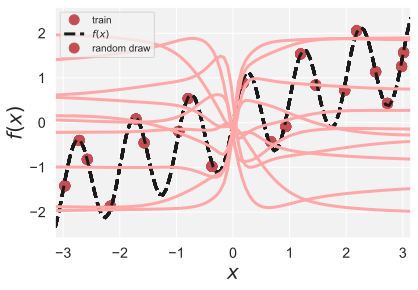

In [105]:
# init_fn, apply_fn, kernel_fn = stax.serial(
#     stax.Dense(512, W_std=1.5, b_std=0.05), stax.Erf(),
#     stax.Dense(512, W_std=1.5, b_std=0.05), stax.Erf(),
#     stax.Dense(512, W_std=1.5, b_std=0.05), stax.Erf(),
#     stax.Dense(1, W_std=1.5, b_std=0.05)
# )

# BNN Setup
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(64, W_std=1.5, b_std=0.05), stax.Erf(),
    stax.Dense(64, W_std=1.5, b_std=0.05), stax.Erf(),
    stax.Dense(64, W_std=1.5, b_std=0.05), stax.Erf(),
    stax.Dense(1,  W_std=1.5, b_std=0.05)
)

apply_fn = jit(apply_fn)
kernel_fn = jit(kernel_fn, static_argnames='get')

# random parameter draws
prior_draws = []
for _ in range(10):
  key, net_key = random.split(key)
  _, params = init_fn(net_key, (-1, 1))
  prior_draws += [apply_fn(params, test_xs)]

  plot_fn(train, test)

for p in prior_draws:
  plt.plot(test_xs, p, linewidth=3, color=[1, 0.65, 0.65])

legend(['train', '$f(x)$', 'random draw'], loc='upper left')

finalize_plot((0.85, 0.6))

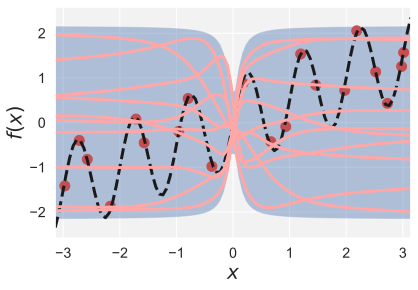

In [106]:
# look at exact prior over functions in infinite-width limit using kernel_fn
# kernel function has signature kernel = kernel_fn (x1, x2): computes kernel between two input sets
# kernel_fn can compute two different kernels: NNGP kernel and NT kernel
# NNGP: Bayesian infinite network
# NT kernel: evolution under gradient descent

kernel = kernel_fn(test_xs, test_xs, 'nngp')
std_dev = jnp.sqrt(jnp.diag(kernel))

plot_fn(train, test)

plt.fill_between(
    jnp.reshape(test_xs, (-1,)), 2 * std_dev, -2 * std_dev, alpha=0.4)

for p in prior_draws:
  plt.plot(test_xs, p, linewidth=3, color=[1, 0.65, 0.65])

finalize_plot((0.85, 0.6))

### Infinite width inference

- Use infinite-width GP to perform exact Bayesian inference using infinite width network
- use function `neural_tangents.predict.gradient_descent_mse_ensemble`
- `predict_fn = nt.predict.gradient_descent_mse_ensemble(kernel_fn, train_xs, train_ys); mean, cov = predict_fn(x_test=test_xs, get='ntk', compute_cov=True)` computes the mean and covariance of the network
- `predict_fn` has two modes: NNGP (Bayesian posterior) and NTK (distribution of networks after gradient descent)

Use this for a more linear kernel approach

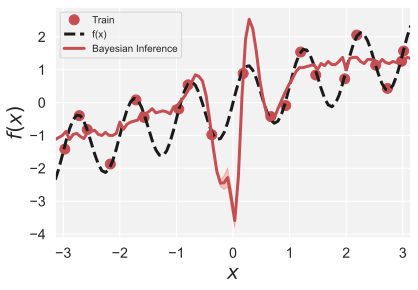

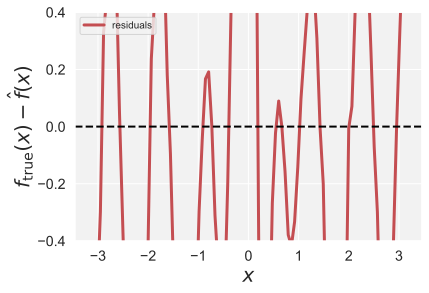

In [107]:
# start with Bayesian inference (NNGP setting)

predict_fn = nt.predict.gradient_descent_mse_ensemble(kernel_fn, train_xs,
                                                      train_ys, diag_reg=5e-6) #former 1e-4

nngp_mean, nngp_covariance = predict_fn(x_test=test_xs, get='nngp',
                                        compute_cov=True)

nngp_mean = jnp.reshape(nngp_mean, (-1,))
nngp_std = jnp.sqrt(jnp.diag(nngp_covariance))

plot_fn(train, test)

plt.plot(test_xs, nngp_mean, 'r-', linewidth=3)
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    nngp_mean - 2 * nngp_std,
    nngp_mean +  2 * nngp_std,
    color='red', alpha=0.2, label='_nolegend_')
# plt.xlim([-jnp.pi, jnp.pi])
# plt.ylim([-1.5, 1.5])
legend(['Train', 'f(x)', 'Bayesian Inference'], loc='upper left')
finalize_plot((0.85, 0.6))

residuals = np.array(test_ys).ravel() - nngp_mean.ravel()

plt.figure()
plt.plot(test_xs, residuals.reshape(-1, 1), 'r-', linewidth=3, label='residuals')
plt.axhline(0, linestyle='--', color='black', linewidth=2)
format_plot('$x$', r'$f_{\mathrm{true}}(x) - \hat{f}(x)$')
legend(loc='upper left')
finalize_plot((0.85, 0.6))
plt.ylim([-0.4, 0.4])
plt.show()

! Use this for a periodic kernel !

Introduce a periodic kernel to mimic sin behaviour since we know it's periodic

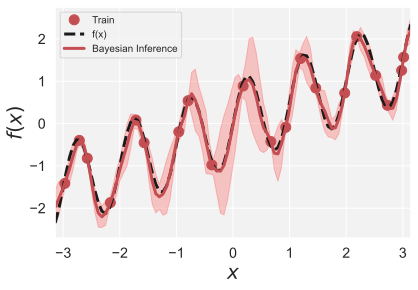

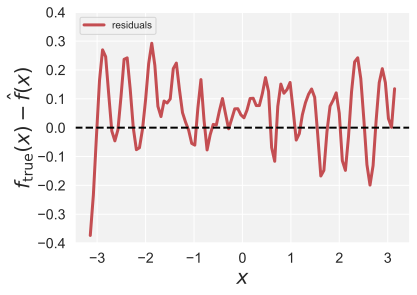

In [108]:
def periodic_kernel_fn(kernel_fn, x1, x2, get='nngp', period=1.0):
    """Apply periodic+linear feature map before calling kernel_fn."""
    def fe(x):
        if x is None:
            return None
        # x = jnp.atleast_2d(x)               
        w = (2 * jnp.pi / period) * x
        return jnp.concatenate([x, jnp.cos(w), jnp.sin(w)], axis=-1)

    return kernel_fn(fe(x1), fe(x2), get=get)


predict_fn = nt.predict.gradient_descent_mse_ensemble(
    lambda x1, x2, get: periodic_kernel_fn(kernel_fn, x1, x2, get, period=1.0),
    train_xs,
    train_ys,
    diag_reg=1e-4
)

nngp_mean, nngp_cov = predict_fn(x_test=test_xs, get='nngp', compute_cov=True)
nngp_mean = nngp_mean.reshape(-1)
nngp_std  = jnp.sqrt(jnp.diag(nngp_cov))

plot_fn(train, test)

plt.plot(test_xs, nngp_mean, 'r-', linewidth=3)
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    nngp_mean - 2 * nngp_std,
    nngp_mean +  2 * nngp_std,
    color='red', alpha=0.2, label='_nolegend_')
# plt.xlim([-jnp.pi, jnp.pi])
# plt.ylim([-1.5, 1.5])
legend(['Train', 'f(x)', 'Bayesian Inference'], loc='upper left')
finalize_plot((0.85, 0.6))

residuals = np.array(test_ys).ravel() - nngp_mean.ravel()

plt.figure()
plt.plot(test_xs, residuals.reshape(-1, 1), 'r-', linewidth=3, label='residuals')
plt.axhline(0, linestyle='--', color='black', linewidth=2)
format_plot('$x$', r'$f_{\mathrm{true}}(x) - \hat{f}(x)$')
legend(loc='upper left')
finalize_plot((0.85, 0.6))
plt.ylim([-0.4, 0.4])
plt.show()


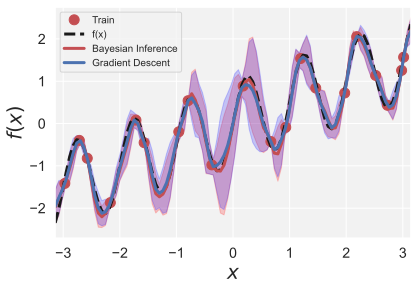

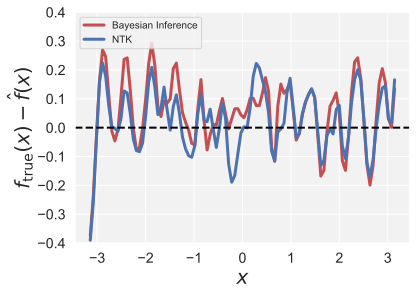

In [109]:
# Results of NTK: gradient descent on infinite network with infinite amount of time

ntk_mean, ntk_covariance = predict_fn(x_test=test_xs, get='ntk',
                                      compute_cov=True)

ntk_mean = jnp.reshape(ntk_mean, (-1,))
ntk_std = jnp.sqrt(jnp.diag(ntk_covariance))

plot_fn(train, test)

plt.plot(test_xs, nngp_mean, 'r-', linewidth=3)
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    nngp_mean - 2 * nngp_std,
    nngp_mean +  2 * nngp_std,
    color='red', alpha=0.2, label='_nolegend_')
plt.plot(test_xs, ntk_mean, 'b-', linewidth=3)
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    ntk_mean - 2 * ntk_std,
    ntk_mean +  2 * ntk_std,
    color='blue', alpha=0.2, label='_nolegend_')
plt.xlim([-jnp.pi, jnp.pi])
# plt.ylim([-1.5, 1.5])
legend(['Train', 'f(x)', 'Bayesian Inference', 'Gradient Descent'],
       loc='upper left')
finalize_plot((0.85, 0.6))

residuals_nngp = np.array(test_ys).ravel() - nngp_mean.ravel()
residuals_ntk = np.array(test_ys).ravel() - ntk_mean.ravel()
plt.figure()
plt.plot(test_xs, residuals_nngp.reshape(-1, 1), 'r-', linewidth=3, label='Bayesian Inference')
plt.plot(test_xs, residuals_ntk.reshape(-1, 1), 'b-', linewidth=3, label='NTK')
plt.axhline(0, linestyle='--', color='black', linewidth=2)
format_plot('$x$', r'$f_{\mathrm{true}}(x) - \hat{f}(x)$')
legend(loc='upper left')
finalize_plot((0.85, 0.6))
plt.ylim([-0.4, 0.4])
plt.show()

### Plot with comparison of RBF, Bayesian Inference and Gradient descent

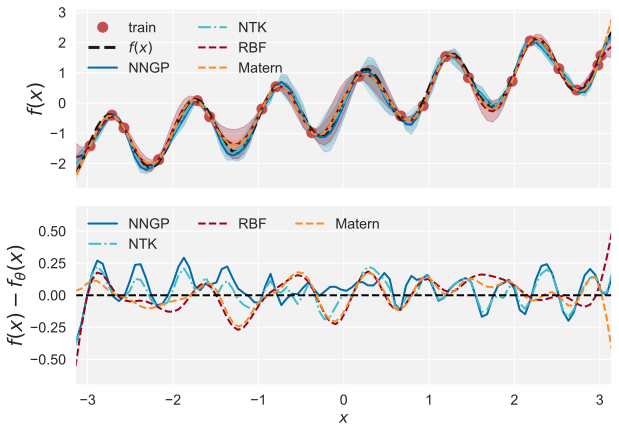

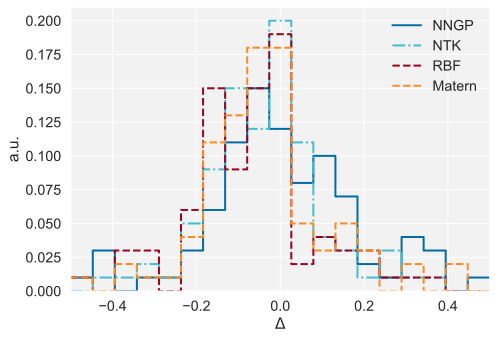

In [110]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True            # single shared x-axis
)

# =======================
#       TOP PANEL
# =======================
plt.sca(ax_top)

plot_fn(train, test)

plt.plot(test_xs, nngp_mean, linestyle='-', color='#006ba6', linewidth=2, label='NNGP')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    nngp_mean - nngp_std,
    nngp_mean + nngp_std,
    color='#006ba6', alpha=0.2, label='_nolegend_'
)

plt.plot(test_xs, ntk_mean, linestyle='-.', color='#43bccd', linewidth=2, label='NTK')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    ntk_mean - ntk_std,
    ntk_mean + ntk_std,
    color='#43bccd', alpha=0.2, label='_nolegend_'
)

plt.plot(test_xs, gp_mean_fn(test_xs), linewidth=2, linestyle='dashed', color='#9A031E', label='RBF')
plt.fill_between(X_test_np.ravel(), lo, hi, alpha=0.25, color='#9A031E', label='_nolegend_')

plt.plot(test_xs, gp_mean_matern_fn(test_xs), '--', linewidth=2, color='#FB8B24', label='Matern')
plt.fill_between(X_test_np.ravel(), lo_matern, hi_matern, alpha=0.25, color='#FB8B24')

plt.xlim([-jnp.pi, jnp.pi])
plt.legend(
    loc='upper left', frameon=False, ncol=2
)

# Remove x-labels from top panel
plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)

finalize_plot((0.85, 0.6))


# =======================
#     BOTTOM PANEL
# =======================
plt.sca(ax_bottom)

residuals_nngp = np.array(test_ys).ravel() - nngp_mean.ravel()
residuals_ntk = np.array(test_ys).ravel() - ntk_mean.ravel()
residuals_rbf = np.array(test_ys).ravel() - gp_mean_fn(test_xs).ravel()

plt.plot(test_xs, residuals_nngp, linestyle='-', color='#006ba6', linewidth=2, label='NNGP')
plt.plot(test_xs, residuals_ntk, linestyle='-.', color='#43bccd', linewidth=2, label='NTK')
# plt.plot(test_xs, residuals_rbf, linestyle='dashed', color='#ffbc42', linewidth=2, label='RBF')
plt.plot(test_xs, residuals_rbf, '--', color='#9A031E', linewidth=2, label='RBF')
plt.plot(test_xs, residuals_matern, '--', color='#FB8B24', linewidth=2, label='Matern')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_{\theta}(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False, ncol=3)
plt.ylim([-0.7, 0.7])


# =======================
#     SAVE FIGURE
# =======================
plt.tight_layout()
plt.savefig("figs/Bayes_NTK_RBF_combined.pdf")
plt.show()
plt.close()

dup = lambda a: np.append(a, a[-1])
delta_ntk = (ntk_mean.ravel() - np.array(test_ys).ravel()) / np.array(test_ys).ravel()
delta_nngp = (nngp_mean.ravel() - np.array(test_ys).ravel()) / np.array(test_ys).ravel()
fig, axs = plt.subplots( 1, 1, figsize=(7,5))
fig.tight_layout(pad=0.0, w_pad=0.0, h_pad=0.0, rect=(0.08, 0.08, 0.99, 0.95))
hist1, bins = np.histogram(delta_rbf.flatten(), bins=np.linspace(-0.5, 0.5, 20))
hist1 = hist1/ len(delta_rbf)
hist2, bins = np.histogram(delta_matern.flatten(), bins=np.linspace(-0.5, 0.5, 20))
hist2 = hist2/ len(delta_matern)
hist3, bins = np.histogram(delta_nngp.flatten(), bins=np.linspace(-0.5, 0.5, 20))
hist3 = hist3/ len(delta_nngp)
hist4, bins = np.histogram(delta_ntk.flatten(), bins=np.linspace(-0.5, 0.5, 20))
hist4 = hist4/ len(delta_ntk)
axs.step(bins, dup(hist3), color='#006ba6', linestyle='solid', label='NNGP', where='post', linewidth=2)
axs.step(bins, dup(hist4), color='#43bccd', linestyle='dashdot', label='NTK', where='post', linewidth=2)
axs.step(bins, dup(hist1), color='#9A031E', linestyle='dashed', label='RBF', where='post', linewidth=2)
axs.step(bins, dup(hist2), color='#FB8B24', linestyle='dashed', label='Matern', where='post', linewidth=2)
axs.set_xlabel('$\\Delta$')
axs.set_xlim([-0.5, 0.5])
axs.set_ylim(0.0)
axs.set_ylabel('a.u.')
axs.legend(frameon=False, loc='upper right')
plt.show()
plt.close()


### infinite width mse loss

In [117]:
# perform finite-time inference
# use this to predict mean of train and test losses
# compute MSE loss while access mean and variance as function over time
# t=None: infinite time

ts = jnp.arange(0, 10 ** 3, 10 ** -1)
ntk_train_loss_mean = loss_fn(predict_fn, train_ys, ts)
ntk_test_loss_mean = loss_fn(predict_fn, test_ys, ts, test_xs)

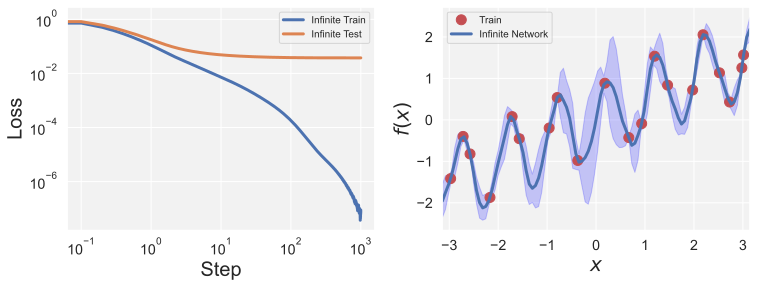

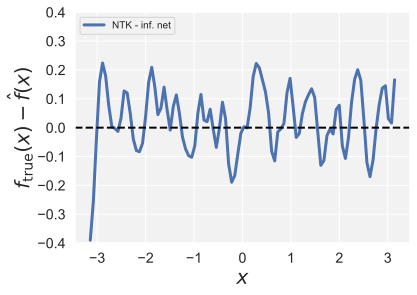

In [118]:
plt.subplot(1, 2, 1)

plt.loglog(ts, ntk_train_loss_mean, linewidth=3)
plt.loglog(ts, ntk_test_loss_mean, linewidth=3)
format_plot('Step', 'Loss')
legend(['Infinite Train', 'Infinite Test'])

plt.subplot(1, 2, 2)

plot_fn(train, None)

plt.plot(test_xs, ntk_mean, 'b-', linewidth=3)
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    ntk_mean - 2 * ntk_std,
    ntk_mean +  2 * ntk_std,
    color='blue', alpha=0.2, label='_nolegend_')

legend(
    ['Train', 'Infinite Network'],
    loc='upper left')

finalize_plot((1.5, 0.6))

residuals_infnet = np.array(test_ys).ravel() - ntk_mean.ravel()
plt.figure()
plt.plot(test_xs, residuals_ntk.reshape(-1, 1), 'b-', linewidth=3, label='NTK - inf. net')
plt.axhline(0, linestyle='--', color='black', linewidth=2)
format_plot('$x$', r'$f_{\mathrm{true}}(x) - \hat{f}(x)$')
legend(loc='upper left')
finalize_plot((0.85, 0.6))
plt.ylim([-0.4, 0.4])
plt.show()

### Training a Neural Network - MSE

- Compare results of gradient descent GP-inference to train an ensemble of finite width networks
- Start by training single network drawn from prior
- Then generalize it to ensemble
- use JAX's gradient descent optimizer

In [107]:
def phi(x, K=1):
    x = jnp.atleast_2d(x)
    w = 2 * jnp.pi * x
    feats = [x] + [jnp.sin(k*w) for k in range(1, K+1)] + [jnp.cos(k*w) for k in range(1, K+1)]
    return jnp.concatenate(feats, axis=-1)   # shape: (n, 1 + 2K)

# map inputs once
Xtr, ytr = train
Xte, yte = test
Xtr_phi, Xte_phi = phi(Xtr), phi(Xte)


In [108]:
learning_rate = 0.001
training_steps = 10000

opt_init, opt_update, get_params = optimizers.sgd(learning_rate)
opt_update = jit(opt_update)

In [229]:
# Define loss and gradient od loss using MSE

loss = jit(lambda params, x, y: 0.5 * jnp.mean((apply_fn(params, phi(x)) - y) ** 2))
grad_loss = jit(lambda state, x, y: grad(loss)(get_params(state), x, y))

In [230]:
train_losses = []
test_losses = []
snapshots = {}

# evaluation checkpoints
# eval_steps = [0, 16, 256, 2048, 4096, 8192, 10000]
eval_steps = [0, 256, 4096, 10000]

key = random.PRNGKey(0)
_, params = init_fn(key, (-1, Xtr_phi.shape[-1]))
opt_state = opt_init(params)

for i in range(training_steps + 1):
    # record predictions at chosen steps
    if i in eval_steps:
        preds = apply_fn(get_params(opt_state), Xte_phi)  # you already preprocessed Xte_phi
        snapshots[i] = np.asarray(preds).ravel()

    # do SGD update (skip after final step)
    if i < training_steps:
        opt_state = opt_update(i, grad_loss(opt_state, *train), opt_state)

        # track losses (same as before)
        train_losses += [loss(get_params(opt_state), *train)]
        test_losses  += [loss(get_params(opt_state), *test)]


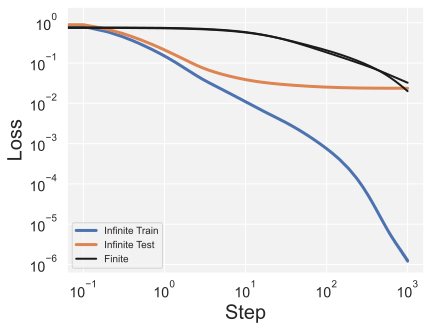

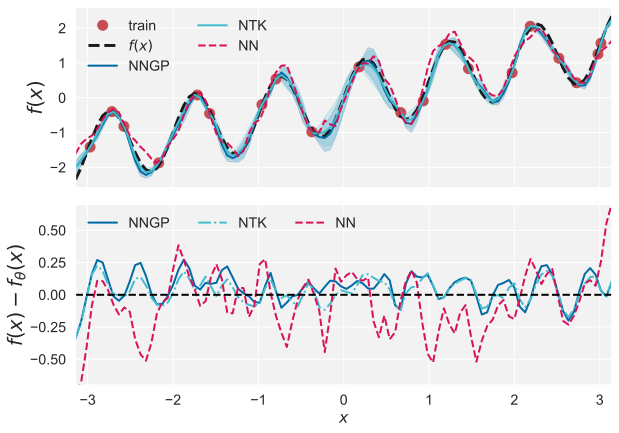

In [231]:
nn_pred = apply_fn(get_params(opt_state), phi(test_xs)).reshape(-1)

plt.loglog(ts, ntk_train_loss_mean, linewidth=3)
plt.loglog(ts, ntk_test_loss_mean, linewidth=3)

plt.loglog(ts, train_losses, 'k-', linewidth=2)
plt.loglog(ts, test_losses, 'k-', linewidth=2)

format_plot('Step', 'Loss')
legend(['Infinite Train', 'Infinite Test', 'Finite'])

# residuals and pred plot
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True            # single shared x-axis
)

plt.sca(ax_top)

plot_fn(train, test)

plt.plot(test_xs, nngp_mean, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    nngp_mean - nngp_std,
    nngp_mean + nngp_std,
    color='#006BA6', alpha=0.2, label='_nolegend_')

plt.plot(test_xs, ntk_mean, linestyle='-', color='#43BCCD', linewidth=2, label='NTK')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    ntk_mean - ntk_std,
    ntk_mean +  ntk_std,
    color='#43BCCD', alpha=0.2, label='_nolegend_')

plt.plot(jnp.reshape(test_xs, (-1,)), nn_pred, linestyle='--', color='#D81159', linewidth=2, label='NN')


plt.xlim([-jnp.pi, jnp.pi])
plt.legend(
    loc='upper left', frameon=False, ncol=2
)

plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_nngp = np.array(test_ys).ravel() - nngp_mean.ravel()
residuals_ntk = np.array(test_ys).ravel() - ntk_mean.ravel()
residuals_net = np.array(test_ys).ravel() - nn_pred.ravel()

plt.plot(test_xs, residuals_nngp, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
plt.plot(test_xs, residuals_ntk, linestyle='-.', color='#43BCCD', linewidth=2, label='NTK')
plt.plot(test_xs, residuals_net, linestyle='--', color='#D81159', linewidth=2, label='NN')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_{\theta}(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False, ncol=3)
plt.ylim([-0.7, 0.7])

plt.tight_layout()
plt.savefig("figs/NNGP_NTK_NN.pdf")
plt.show()
plt.close()

In [235]:
# Convert discrete eval steps -> continuous NTK "time"
training_steps = 10000
eval_steps = np.array([0, 256, 4096, 10000])
learning_rate = 0.001
eval_ts = eval_steps * learning_rate

# Make sure x is sorted for clean plotting
xline = np.asarray(test_xs).ravel()
sort_idx = np.argsort(xline)
xline_sorted = xline[sort_idx]

train_x = np.asarray(train_xs).ravel()
train_y = np.asarray(train_ys).ravel()

# --- vectorized predictions over all eval_ts in one shot ---
# NNGP
g_mean, g_cov = predict_fn(t=eval_ts, get='nngp', x_test=test_xs, compute_cov=True)
g_mean = np.asarray(g_mean)[:, :, 0].reshape(len(eval_ts), -1)  # (T, n_test)
g_var  = np.diagonal(np.asarray(g_cov), axis1=1, axis2=2)       # (T, n_test)
g_std  = np.sqrt(np.clip(g_var, 0, np.inf))

# NTK
k_mean, k_cov = predict_fn(t=eval_ts, get='ntk', x_test=test_xs, compute_cov=True)
k_mean = np.asarray(k_mean)[:, :, 0].reshape(len(eval_ts), -1)  # (T, n_test)
k_var  = np.diagonal(np.asarray(k_cov), axis1=1, axis2=2)
k_std  = np.sqrt(np.clip(k_var, 0, np.inf))


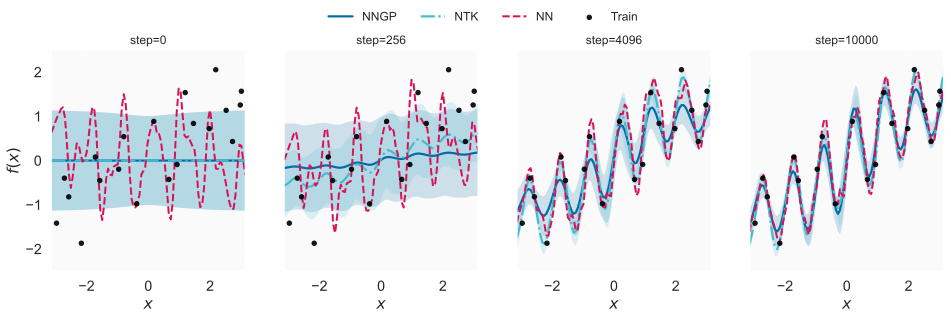

In [236]:
#plots
fig, axes = plt.subplots(
    1, len(eval_steps),
    figsize=(4.0 * len(eval_steps), 4),
    sharey=True
)

for ax in axes:
    ax.set_facecolor((0.98, 0.98, 0.98))

band_mult = 1. 

for i, (ax, step, t) in enumerate(zip(axes, eval_steps, eval_ts)):
    # NNGP
    m_nngp = g_mean[i][sort_idx]
    s_nngp = g_std[i][sort_idx]
    ax.plot(xline_sorted, m_nngp, lw=2.2, ls='-', color='#006BA6',
            label='NNGP' if i == 0 else None)
    ax.fill_between(xline_sorted, m_nngp - band_mult*s_nngp, m_nngp + band_mult*s_nngp,
                    color='#006BA6', alpha=0.18, linewidth=0)

    # NTK
    m_ntk = k_mean[i][sort_idx]
    s_ntk= k_std[i][sort_idx]
    ax.plot(xline_sorted, m_ntk, lw=2.2, ls='-.', color='#43BCCD',
            label='NTK' if i == 0 else None)
    ax.fill_between(xline_sorted, m_ntk - band_mult*s_ntk, m_ntk + band_mult*s_ntk,
                    color='#43BCCD', alpha=0.18, linewidth=0)

    # Finite NN snapshot (assumes snapshots keyed by *step*, not t)
    nn_snap_1mem = np.asarray(snapshots[step]).ravel()[sort_idx]
    ax.plot(xline_sorted, nn_snap_1mem, lw=2.0, ls='--', color='#D81159',
            label='NN' if i == 0 else None)

    # Training data
    ax.scatter(train_x, train_y, s=20, color='black', alpha=0.9,
               label='Train' if i == 0 else None, zorder=3)

    ax.set_title(fr"step={step}", fontsize=12)
    ax.set_xlim([-np.pi, np.pi])
    ax.set_ylim([-2.5, 2.5])
    ax.grid(alpha=0.25, linestyle='--')
    ax.set_xlabel("$x$")

axes[0].set_ylabel("$f(x)$")

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels),
           frameon=False, fontsize=12, bbox_to_anchor=(0.5, 1.05))

plt.savefig("figs/timeevol_single.pdf", bbox_inches="tight")
plt.show()


### Train Ensemble of Neural Networks

- use vmap in JAX to vectorize the ensemble members

In [237]:
def train_network(key, eval_steps=None):
    if eval_steps is None:
        eval_steps = []
    train_losses, test_losses = [], []
    snapshots = {}

    input_dim = phi(train[0]).shape[-1]
    _, params = init_fn(key, (-1, input_dim))
    opt_state = opt_init(params)

    for i in range(training_steps + 1):
        # record predictions only if eval_steps was provided
        if i in eval_steps:
            preds = apply_fn(get_params(opt_state), phi(test[0])).squeeze(-1)
            snapshots[i] = np.asarray(preds)

        if i < training_steps:
            train_losses.append(jnp.reshape(loss(get_params(opt_state), *train), (1,)))
            test_losses.append(jnp.reshape(loss(get_params(opt_state), *test), (1,)))
            opt_state = opt_update(i, grad_loss(opt_state, *train), opt_state)


    if eval_steps and len(eval_steps) > 0:
        return get_params(opt_state), jnp.concatenate(train_losses), jnp.concatenate(test_losses), snapshots
    else:
        return get_params(opt_state), jnp.concatenate(train_losses), jnp.concatenate(test_losses)



In [238]:
# test {"skip": true}
params_nn, train_loss_nn, test_loss_nn = train_network(key)

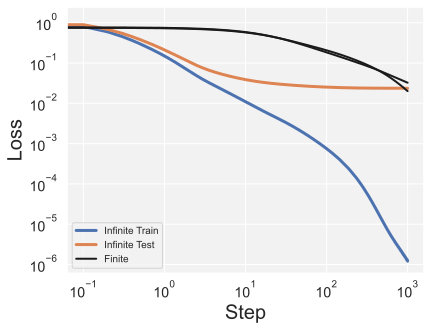

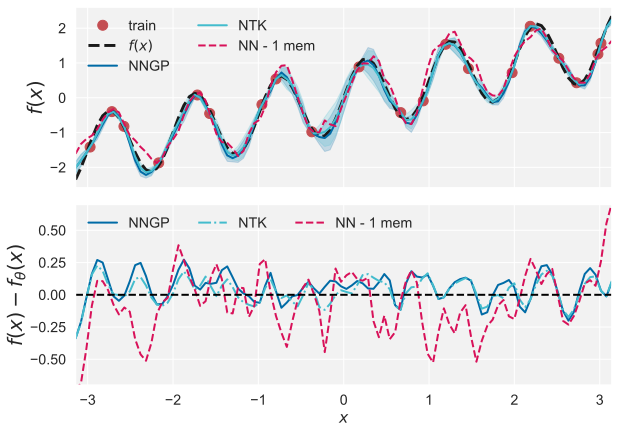

In [239]:
finite_net_1mem_noreshape =  apply_fn(get_params(opt_state), phi(test_xs))
finite_net_1mem =  apply_fn(get_params(opt_state), phi(test_xs)).reshape(-1)

plt.loglog(ts, ntk_train_loss_mean, linewidth=3)
plt.loglog(ts, ntk_test_loss_mean, linewidth=3)

plt.loglog(ts, train_loss_nn, 'k-', linewidth=2)
plt.loglog(ts, test_loss_nn, 'k-', linewidth=2)

format_plot('Step', 'Loss')
legend(['Infinite Train', 'Infinite Test', 'Finite'])

# residuals and pred plot
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True            # single shared x-axis
)

plt.sca(ax_top)

plot_fn(train, test)

plt.plot(test_xs, nngp_mean, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    nngp_mean - nngp_std,
    nngp_mean + nngp_std,
    color='#006BA6', alpha=0.2, label='_nolegend_')

plt.plot(test_xs, ntk_mean, linestyle='-', color='#43BCCD', linewidth=2, label='NTK')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    ntk_mean - ntk_std,
    ntk_mean + ntk_std,
    color='#43BCCD', alpha=0.2, label='_nolegend_')

plt.plot(jnp.reshape(test_xs, (-1,)), finite_net_1mem, linestyle='--', color='#D81159', linewidth=2, label='NN - 1 mem')


plt.xlim([-jnp.pi, jnp.pi])
plt.legend(
    loc='upper left', frameon=False, ncol=2
)

plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_nngp = np.array(test_ys).ravel() - nngp_mean.ravel()
residuals_ntk = np.array(test_ys).ravel() - ntk_mean.ravel()
residuals_net = np.array(test_ys).ravel() - finite_net_1mem.ravel()

plt.plot(test_xs, residuals_nngp, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
plt.plot(test_xs, residuals_ntk, linestyle='-.', color='#43BCCD', linewidth=2, label='NTK')
plt.plot(test_xs, residuals_net, linestyle='--', color='#D81159', linewidth=2, label='NN - 1 mem')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_{\theta}(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False, ncol=3)
plt.ylim([-0.7, 0.7])

plt.tight_layout()
plt.savefig("figs/NNGP_NTK_NN1mem.pdf")
plt.show()
plt.close()

In [240]:
# test {"skip": true}
ensemble_size = 10
ensemble_key = random.split(key, ensemble_size)

# manually loop to store snapshots
eval_steps = [0, 256, 4096, 10000]
ensemble_outs_10mem = [train_network(k, eval_steps=eval_steps) for k in ensemble_key]

params_ens10, train_loss_ens10, test_loss_ens10 = zip(*[o[:3] for o in ensemble_outs_10mem])
snapshots_list_10mem = [o[3] for o in ensemble_outs_10mem]

In [241]:
ens_10mem = {}
for t in eval_steps:
    stack_10mem = jnp.stack([s[t] for s in snapshots_list_10mem], axis=0)  # (ensemble_size, n_test)
    ens_10mem[t] = (stack_10mem.mean(0), stack_10mem.std(0, ddof=1))

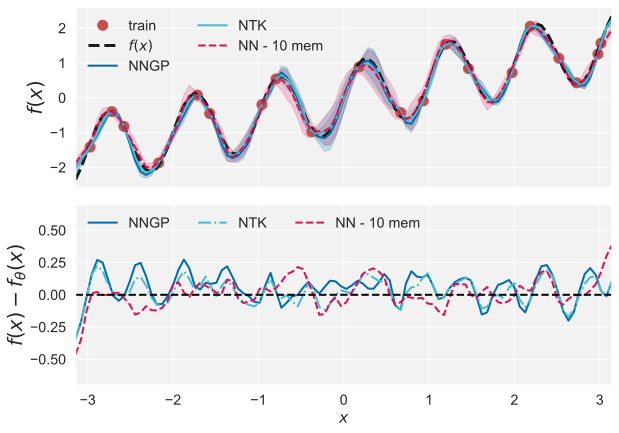

In [242]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True            # single shared x-axis
)

plt.sca(ax_top)

plot_fn(train, test)

plt.plot(test_xs, nngp_mean, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    nngp_mean - nngp_std,
    nngp_mean + nngp_std,
    color='#006BA6', alpha=0.2, label='_nolegend_')

plt.plot(test_xs, ntk_mean, linestyle='-', color='#43BCCD', linewidth=2, label='NTK')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    ntk_mean - ntk_std,
    ntk_mean + ntk_std,
    color='#43BCCD', alpha=0.2, label='_nolegend_')

phi_test = phi(test_xs)

# params is a tuple/list of pytrees: length = ensemble_size
ensemble_fx_10mem = jnp.stack(
    [apply_fn(p, phi_test).reshape(-1) for p in params_ens10],
    axis=0
)  # shape = (ensemble_size, n_test)
mean_fx_10mem = jnp.mean(ensemble_fx_10mem, axis=0)
std_fx_10mem  = jnp.std(ensemble_fx_10mem, axis=0)

plt.plot(test_xs, mean_fx_10mem, linestyle='--', color='#D81159', linewidth=2, label='NN - 10 mem')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    mean_fx_10mem - std_fx_10mem,
    mean_fx_10mem + std_fx_10mem,
    color='#D81159', alpha=0.2, label='_nolegend_')

plt.xlim([-jnp.pi, jnp.pi])
plt.legend(
    loc='upper left', frameon=False, ncol=2
)

plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))

plt.sca(ax_bottom)

residuals_nngp = np.array(test_ys).ravel() - nngp_mean.ravel()
residuals_ntk = np.array(test_ys).ravel() - ntk_mean.ravel()
residuals_nn_10mem = np.array(test_ys).ravel() - mean_fx_10mem.ravel()

plt.plot(test_xs, residuals_nngp, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
plt.plot(test_xs, residuals_ntk, linestyle='-.', color='#43BCCD', linewidth=2, label='NTK')
plt.plot(test_xs, residuals_nn_10mem, linestyle='--', color='#D81159', linewidth=2, label='NN - 10 mem')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_{\theta}(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False, ncol=3)
plt.ylim([-0.7, 0.7])

plt.tight_layout()
plt.savefig("figs/NNGP_NTK_NN10mem.pdf")
plt.show()
plt.close()

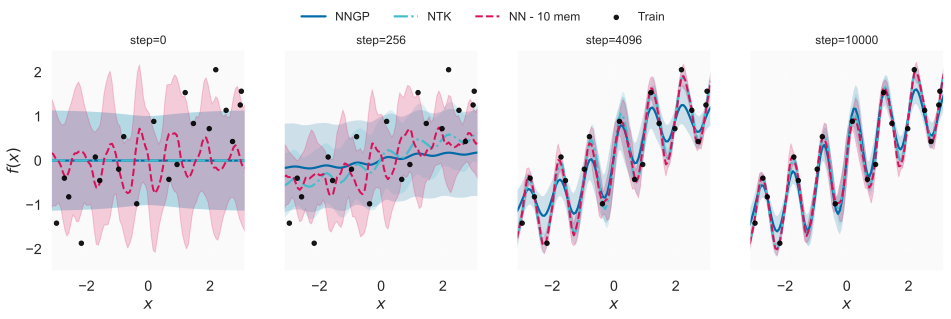

In [ ]:
#plots
fig, axes = plt.subplots(
    1, len(eval_steps),
    figsize=(4.0 * len(eval_steps), 4),
    sharey=True
)

for ax in axes:
    ax.set_facecolor((0.98, 0.98, 0.98))

band_mult = 1   # instead of 2

for i, (ax, step, t) in enumerate(zip(axes, eval_steps, eval_ts)):
    # NNGP
    m_nngp = g_mean[i][sort_idx]
    s_nngp = g_std[i][sort_idx]
    ax.plot(xline_sorted, m_nngp, lw=2.2, ls='-', color='#006BA6',
            label='NNGP' if i == 0 else None)
    ax.fill_between(xline_sorted, m_nngp - band_mult*s_nngp, m_nngp + band_mult*s_nngp,
                    color='#006BA6', alpha=0.18, linewidth=0)

    # NTK
    m_ntk = k_mean[i][sort_idx]
    s_ntk = k_std[i][sort_idx]
    ax.plot(xline_sorted, m_ntk, lw=2.2, ls='-.', color='#43BCCD',
            label='NTK' if i == 0 else None)
    ax.fill_between(xline_sorted, m_ntk - band_mult*s_ntk, m_ntk + band_mult*s_ntk,
                    color='#43BCCD', alpha=0.18, linewidth=0)

    # Finite NN snapshot (assumes snapshots keyed by *step*, not t)
    mean_t_10mem, std_t_10mem = ens_10mem[step]
    ax.plot(xline, mean_t_10mem, color='#D81159', lw=2, linestyle='dashed',
            label='NN - 10 mem' if t == eval_steps[0] else None)
    ax.fill_between(xline, mean_t_10mem - band_mult*std_t_10mem, mean_t_10mem + band_mult*std_t_10mem,
                    color='#D81159', alpha=0.2)

    # Training data
    ax.scatter(train_x, train_y, s=20, color='black', alpha=0.9,
               label='Train' if i == 0 else None, zorder=3)

    ax.set_title(fr"step={step}", fontsize=12)
    ax.set_xlim([-np.pi, np.pi])
    ax.set_ylim([-2.5, 2.5])
    ax.grid(alpha=0.25, linestyle='--')
    ax.set_xlabel("$x$")

axes[0].set_ylabel("$f(x)$")

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels),
           frameon=False, fontsize=12, bbox_to_anchor=(0.5, 1.05))

plt.savefig("figs/timeevol_10mem.pdf", bbox_inches="tight")
plt.show()


In [244]:
# test {"skip": true}
ensemble_size = 50
ensemble_key = random.split(key, ensemble_size)

# manually loop to store snapshots
eval_steps = [0, 256, 4096, 10000]
ensemble_outs_50mem = [train_network(k, eval_steps=eval_steps) for k in ensemble_key]

params_50mem, train_loss_50mem, test_loss_50mem = zip(*[o[:3] for o in ensemble_outs_50mem])
snapshots_list_50mem = [o[3] for o in ensemble_outs_50mem]

In [245]:
ens_50mem = {}
for t in eval_steps:
    stack_50mem = jnp.stack([s[t] for s in snapshots_list_50mem], axis=0)  # (ensemble_size, n_test)
    ens_50mem[t] = (stack_50mem.mean(0), stack_50mem.std(0, ddof=1))

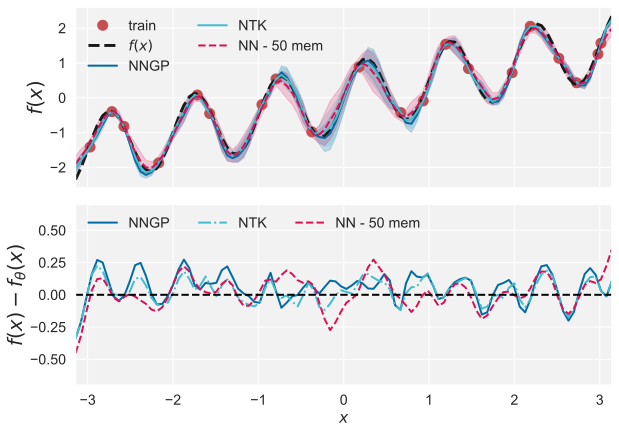

In [246]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True            # single shared x-axis
)

plt.sca(ax_top)

plot_fn(train, test)

plt.plot(test_xs, nngp_mean, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    nngp_mean - nngp_std,
    nngp_mean + nngp_std,
    color='#006BA6', alpha=0.2, label='_nolegend_')

plt.plot(test_xs, ntk_mean, linestyle='-', color='#43BCCD', linewidth=2, label='NTK')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    ntk_mean - ntk_std,
    ntk_mean + ntk_std,
    color='#43BCCD', alpha=0.2, label='_nolegend_')

phi_test = phi(test_xs)

# params is a tuple/list of pytrees: length = ensemble_size
ensemble_fx_50mem = jnp.stack(
    [apply_fn(p, phi_test).reshape(-1) for p in params_50mem],
    axis=0
)  # shape = (ensemble_size, n_test)
mean_fx_50mem = jnp.mean(ensemble_fx_50mem, axis=0)
std_fx_50mem  = jnp.std(ensemble_fx_50mem, axis=0)

plt.plot(test_xs, mean_fx_50mem, linestyle='--', color='#D81159', linewidth=2, label='NN - 50 mem')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    mean_fx_50mem - std_fx_50mem,
    mean_fx_50mem + std_fx_50mem,
    color='#D81159', alpha=0.2, label='_nolegend_')

plt.xlim([-jnp.pi, jnp.pi])
plt.legend(
    loc='upper left', frameon=False, ncol=2
)

plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))

plt.sca(ax_bottom)

residuals_nngp = np.array(test_ys).ravel() - nngp_mean.ravel()
residuals_ntk = np.array(test_ys).ravel() - ntk_mean.ravel()
residuals_nn_50mem = np.array(test_ys).ravel() - mean_fx_50mem.ravel()

plt.plot(test_xs, residuals_nngp, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
plt.plot(test_xs, residuals_ntk, linestyle='-.', color='#43BCCD', linewidth=2, label='NTK')
plt.plot(test_xs, residuals_nn_50mem, linestyle='--', color='#D81159', linewidth=2, label='NN - 50 mem')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_{\theta}(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False, ncol=3)
plt.ylim([-0.7, 0.7])

plt.tight_layout()
plt.savefig("figs/NNGP_NTK_NN50mem.pdf")
plt.show()
plt.close()

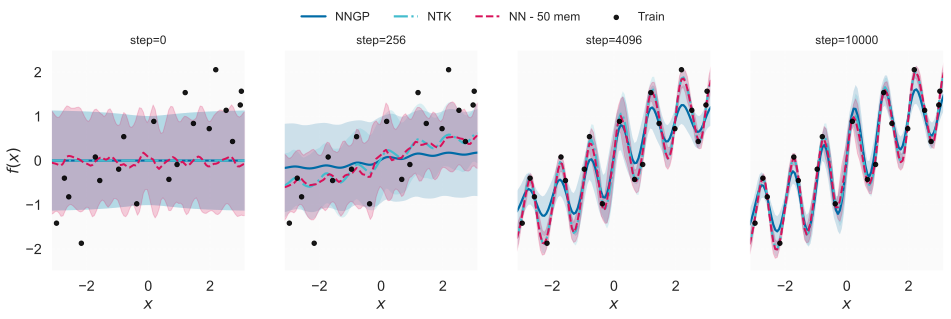

In [ ]:
#plots
fig, axes = plt.subplots(
    1, len(eval_steps),
    figsize=(4.0 * len(eval_steps), 4),
    sharey=True
)

for ax in axes:
    ax.set_facecolor((0.98, 0.98, 0.98))

band_mult = 1   # instead of 2

for i, (ax, step, t) in enumerate(zip(axes, eval_steps, eval_ts)):
    # NNGP
    m_nngp = g_mean[i][sort_idx]
    s_nngp = g_std[i][sort_idx]
    ax.plot(xline_sorted, m_nngp, lw=2.2, ls='-', color='#006BA6',
            label='NNGP' if i == 0 else None)
    ax.fill_between(xline_sorted, m_nngp - band_mult*s_nngp, m_nngp + band_mult*s_nngp,
                    color='#006BA6', alpha=0.18, linewidth=0)

    # NTK
    m_ntk = k_mean[i][sort_idx]
    s_ntk = k_std[i][sort_idx]
    ax.plot(xline_sorted, m_ntk, lw=2.2, ls='-.', color='#43BCCD',
            label='NTK' if i == 0 else None)
    ax.fill_between(xline_sorted, m_ntk - band_mult*s_ntk, m_ntk + band_mult*s_ntk,
                    color='#43BCCD', alpha=0.18, linewidth=0)

    # Finite NN snapshot (assumes snapshots keyed by *step*, not t)
    mean_t_50mem, std_t_50mem = ens_50mem[step]
    ax.plot(xline, mean_t_50mem, color='#D81159', lw=2, linestyle='dashed',
            label='NN - 50 mem' if t == eval_steps[0] else None)
    ax.fill_between(xline, mean_t_50mem - band_mult*std_t_50mem, mean_t_50mem + band_mult*std_t_50mem,
                    color='#D81159', alpha=0.2)

    # Training data
    ax.scatter(train_x, train_y, s=20, color='black', alpha=0.9,
               label='Train' if i == 0 else None, zorder=3)

    ax.set_title(fr"step={step}", fontsize=12)
    ax.set_xlim([-np.pi, np.pi])
    ax.set_ylim([-2.5, 2.5])
    ax.grid(alpha=0.25, linestyle='--')
    ax.set_xlabel("$x$")

axes[0].set_ylabel("$f(x)$")

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels),
           frameon=False, fontsize=12, bbox_to_anchor=(0.5, 1.05))

plt.savefig("figs/timeevol_50mem.pdf", bbox_inches="tight")
plt.show()


## Play around with different architectures

- try BNN structure

### BNN network

In [248]:
class VBLinear(nn.Module):
    def __init__(
        self,
        in_features: int,
        out_features: int,
        prior_prec: float = 1.0,
        map: bool = False,
        std_init: float = -9,
    ):
        super().__init__()
        self.n_in = in_features
        self.n_out = out_features
        self.map = map
        self.prior_prec = prior_prec
        self.random = None
        self.NBOUND = -30 if torch.get_default_dtype() == torch.float64 else -20
        self.eps = 1e-12 if torch.get_default_dtype() == torch.float64 else 1e-8
        self.bias = nn.Parameter(torch.Tensor(out_features))
        self.mu_w = nn.Parameter(torch.Tensor(out_features, in_features))
        self.logsig2_w = nn.Parameter(torch.Tensor(out_features, in_features))
        self.std_init = std_init
        self.reset_parameters()

    def enable_map(self):
        self.map = True

    def disenable_map(self):
        self.map = False

    def reset_parameters(self):
        stdv = 1.0 / math.sqrt(self.mu_w.size(1))
        self.mu_w.data.normal_(0, stdv)
        self.logsig2_w.data.zero_().normal_(self.std_init, 0.001)
        self.bias.data.zero_()

    def reset_random(self):
        self.random = None
        self.map = False

    def sample_random_state(self):
        return torch.randn_like(self.logsig2_w).detach().cpu().numpy()

    def import_random_state(self, state):
        self.random = torch.tensor(
            state, device=self.logsig2_w.device, dtype=self.logsig2_w.dtype
        )

    def KL(self):
        logsig2_w = self.logsig2_w.clamp(self.NBOUND, 11)
        kl = (
            0.5
            * (
                self.prior_prec * (self.mu_w.pow(2) + logsig2_w.exp())
                - logsig2_w
                - 1
                - math.log(self.prior_prec)
            ).sum()
        )
        return kl

    def forward(self, input):
        if self.training:
            # local reparameterization trick is more efficient and leads to
            # an estimate of the gradient with smaller variance.
            # https://arxiv.org/pdf/1506.02557.pdf
            mu_out = F.linear(input, self.mu_w, self.bias)
            logsig2_w = self.logsig2_w.clamp(self.NBOUND, 11)
            s2_w = logsig2_w.exp()
            # Needed to avoid NaNs from gradient of sqrt in next line!
            var_out = F.linear(input.pow(2), s2_w) + self.eps
            return mu_out + var_out.sqrt() * torch.randn_like(mu_out)

        else:
            if self.map:
                return F.linear(input, self.mu_w, self.bias)

            logsig2_w = self.logsig2_w.clamp(self.NBOUND, 11)
            if self.random is None:
                self.random = torch.randn_like(self.mu_w)
            s2_w = logsig2_w.exp()
            weight = self.mu_w + s2_w.sqrt() * self.random
            return F.linear(input, weight, self.bias)

    def __repr__(self):
        return f"{self.__class__.__name__} ({self.n_in}) -> ({self.n_out})"

In [249]:
class BayesNet(nn.Module):
    
    # default hdn_dim is 30, but can be changed upon initialisation
    def __init__(self, training_size, hdn_dim=64, prior_prec=1.0):

        super().__init__()

        # the loss function depends on the amount of training data we have, so we need to store this
        self.training_size = training_size
        
        # the activation layers of the network are not bayesian
        # and we need to be able to access the bayesian layers separately

        self.vb_layers = []
        self.all_layers = []

        # define the input layer
        linear_layer = nn.Linear(1, hdn_dim)
        #vb_layer = VBLinear(1, hdn_dim, prior_prec=prior_prec)
        #self.vb_layers.append(vb_layer)
        #self.all_layers.append(vb_layer)
        self.all_layers.append(linear_layer)
        self.all_layers.append(nn.GELU())

        # loop over hidden layers
        for _ in range(3):
            linear_layer = nn.Linear(hdn_dim, hdn_dim)
            #vb_layer = VBLinear(hdn_dim, hdn_dim, prior_prec=prior_prec)
            #self.vb_layers.append(vb_layer)
            #self.all_layers.append(vb_layer)
            self.all_layers.append(linear_layer)
            self.all_layers.append(nn.GELU())

        # define the output layer
        vb_layer = VBLinear(hdn_dim, 2, prior_prec=prior_prec)
        #linear_layer = nn.Linear(hdn_dim, 2)
        self.vb_layers.append(vb_layer)
        self.all_layers.append(vb_layer)
        #self.all_layers.append(linear_layer)

        # define the model as a Sequential net over all layers
        self.model = nn.Sequential(*self.all_layers)

    # and of course the forward function
    def forward(self, x):
        out = self.model(x)
        return out

    # we need the KL from the bayesian layers to compute the loss function
    def KL(self):
        kl = 0
        for vb_layer in self.vb_layers:
            kl += vb_layer.KL()
        return kl / self.training_size
    
    # let's put the neg_log_gauss in the network class as it is key to bayesian networks
    def neg_log_gauss(self, outputs: torch.Tensor, targets: torch.Tensor):
        mu = outputs[:, 0]
        logsigma2 = outputs[:, 1].clamp(N_BOUND, 11)
        out = 0.5 * ((targets - mu)**2 / logsigma2.exp() + logsigma2)
        return torch.mean(out)
    
    def reset_random(self):
        """
        Reset the random state of all bayesian layers.
        """
        for vb_layer in self.vb_layers:
            vb_layer.reset_random()

In [250]:
# check if we have GPU available or not
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [251]:
def periodic_input_t(x, period=1.0, lam=0.7):
    # lam=0 → raw x (no periodicity), lam=1 → pure sin (fully periodic)
    return (1 - lam) * x + lam * torch.sin(2 * math.pi * x / period)


In [252]:
N_BOUND = -30 if torch.get_default_dtype() == torch.float64 else -20

# 1) Bridge JAX -> Torch tensors (keeps shapes (N,1))
def to_torch(x_jax, y_jax=None, device="cpu"):
    x = torch.tensor(np.asarray(x_jax), dtype=torch.get_default_dtype(), device=device)
    if y_jax is None:
        return x
    y = torch.tensor(np.asarray(y_jax), dtype=torch.get_default_dtype(), device=device)
    return x, y

device = "cuda" if torch.cuda.is_available() else "cpu"

Xtr_t, Ytr_t = to_torch(train_xs, train_ys, device=device)  # (N,1)
Xte_t        = to_torch(test_xs, device=device)             # (N*,1)

# 2) Build model (your BayesNet) + optimizer
model = BayesNet(training_size=Xtr_t.shape[0], hdn_dim=64, prior_prec=1.0).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# 3) Train: NLL (Gaussian with learned log-variance) + KL (already scaled by training_size inside BayesNet.KL)
epochs = 1000
model.train()
for ep in range(epochs):
    opt.zero_grad()
    outputs = model(periodic_input_t(Xtr_t))                            # (N, 2) -> [mu, log_sigma2]
    nll = model.neg_log_gauss(outputs, Ytr_t.squeeze(-1))  # scalar
    kl  = model.KL()                                  # scalar (already /training_size)
    loss = nll + kl
    loss.backward()
    opt.step()
    # if ep % 200 == 0:
    #     print(f"[{ep}] loss={loss.item():.4f}  nll={nll.item():.4f}  kl={kl.item():.4f}")

# 4) MC prediction on test grid
@torch.no_grad()
def mc_predict(model, x, S=200):
    """
    Returns predictive mean and std of y at x by combining:
    total_var = E[exp(logsigma2)] + Var(mu_samples)
    """
    model.eval()
    mu_list = []
    sigma2_list = []
    for _ in range(S):
        model.reset_random()                 # resample VBLinear weights
        out = model(periodic_input_t(x))                       # (N*, 2)
        mu = out[:, 0]
        logs2 = out[:, 1].clamp(N_BOUND, 11)
        mu_list.append(mu)
        sigma2_list.append(logs2.exp())
    mu_s = torch.stack(mu_list, 0)           # (S, N*)
    s2_s = torch.stack(sigma2_list, 0)       # (S, N*)
    mean = mu_s.mean(0)                      # (N*,)
    var  = s2_s.mean(0) + mu_s.var(0, unbiased=True)  # law of total variance
    std  = var.sqrt()
    return mean.cpu().numpy(), std.cpu().numpy()      # (N*,), (N*,)

mu, sd = mc_predict(model, Xte_t, S=200)              # for CI + residuals

# 5) Plotting helpers callback (fast mean for plot_fn; fewer samples)
def bnn_mean_fn(x):
    with torch.no_grad():
        model.eval()
        preds = []
        for _ in range(64):
            model.reset_random()
            preds.append(model(periodic_input_t(Xte_t))[:, 0])         # take only mu
        mu_quick = torch.stack(preds, 0).mean(0).cpu().numpy()
    return mu_quick.reshape(-1, 1)




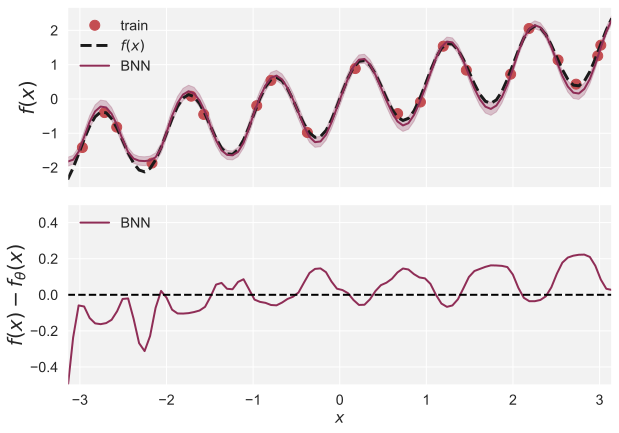

In [253]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True
)

plt.sca(ax_top)
plot_fn(train, test)

plt.plot(test_xs, bnn_mean_fn(test_xs), '-', linewidth=2, color='#8F2D56', label='BNN')
plt.fill_between(jnp.reshape(test_xs, (-1)), mu - sd, mu + sd, alpha=0.25, color='#8F2D56')

plt.xlim([-jnp.pi, jnp.pi])
plt.legend(loc='upper left', frameon=False)
plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_bnn = np.asarray(test_ys).ravel() - mu

plt.plot(test_xs, residuals_bnn, '#8F2D56', linewidth=2, label='BNN')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_\theta(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False)
plt.ylim([-0.5, 0.5])

plt.tight_layout()
plt.savefig("figs/BNN.pdf")
plt.show()
plt.close()


### BNN plots

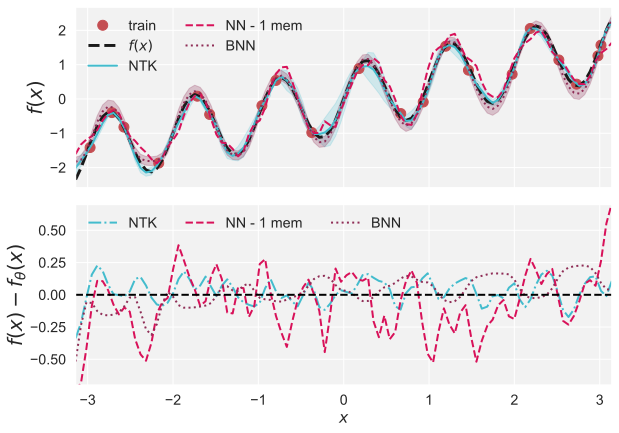

In [254]:
# residuals and pred plot
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True            # single shared x-axis
)

plt.sca(ax_top)

plot_fn(train, test)

# plt.plot(test_xs, nngp_mean, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
# plt.fill_between(
#     jnp.reshape(test_xs, (-1)),
#     nngp_mean - nngp_std,
#     nngp_mean + nngp_std,
#     color='#006BA6', alpha=0.2, label='_nolegend_')

plt.plot(test_xs, ntk_mean, linestyle='-', color='#43BCCD', linewidth=2, label='NTK')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    ntk_mean - ntk_std,
    ntk_mean + ntk_std,
    color='#43BCCD', alpha=0.2, label='_nolegend_')

plt.plot(jnp.reshape(test_xs, (-1,)), finite_net_1mem, linestyle='--', color='#D81159', linewidth=2, label='NN - 1 mem')

bnn_mean_np = np.asarray(bnn_mean_fn(test_xs)).ravel()
mu_np = np.asarray(mu).ravel()
sd_np = np.asarray(sd).ravel()
plt.plot(test_xs, bnn_mean_np, linestyle=':', color='#8F2D56', linewidth=2, label='BNN')
plt.fill_between(
    jnp.reshape(test_xs, (-1)), mu_np - sd_np, mu_np + sd_np,
    color='#8F2D56', alpha=0.25, label='_nolegend_'
)


plt.xlim([-jnp.pi, jnp.pi])
plt.legend(
    loc='upper left', frameon=False, ncol=2
)

plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_bay = np.array(test_ys).ravel() - bnn_mean_np.ravel()
residuals_ntk = np.array(test_ys).ravel() - ntk_mean.ravel()
residuals_net = np.array(test_ys).ravel() - finite_net_1mem.ravel()

plt.plot(test_xs, residuals_ntk, linestyle='-.', color='#43BCCD', linewidth=2, label='NTK')
plt.plot(test_xs, residuals_net, linestyle='--', color='#D81159', linewidth=2, label='NN - 1 mem')
plt.plot(test_xs, residuals_bay, linestyle=':', color='#8F2D56', linewidth=2, label='BNN')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_{\theta}(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False, ncol=3)
plt.ylim([-0.7, 0.7])

plt.tight_layout()
plt.savefig("figs/BNN_NTK_NN1mem.pdf")
plt.show()
plt.close()

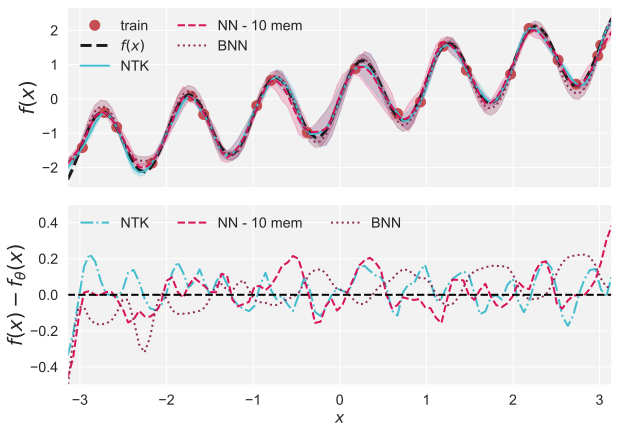

In [255]:
# residuals and pred plot
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True            # single shared x-axis
)

plt.sca(ax_top)

plot_fn(train, test)

# plt.plot(test_xs, nngp_mean, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
# plt.fill_between(
#     jnp.reshape(test_xs, (-1)),
#     nngp_mean - nngp_std,
#     nngp_mean + nngp_std,
#     color='#006BA6', alpha=0.2, label='_nolegend_')

plt.plot(test_xs, ntk_mean, linestyle='-', color='#43BCCD', linewidth=2, label='NTK')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    ntk_mean - ntk_std,
    ntk_mean + ntk_std,
    color='#43BCCD', alpha=0.2, label='_nolegend_')

phi_test = phi(test_xs)

# params is a tuple/list of pytrees: length = ensemble_size
ensemble_fx_10mem = jnp.stack(
    [apply_fn(p, phi_test).reshape(-1) for p in params_ens10],
    axis=0
)  # shape = (ensemble_size, n_test)
mean_fx_10mem = jnp.mean(ensemble_fx_10mem, axis=0)
std_fx_10mem  = jnp.std(ensemble_fx_10mem, axis=0)

plt.plot(test_xs, mean_fx_10mem, linestyle='--', color='#D81159', linewidth=2, label='NN - 10 mem')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    mean_fx_10mem - std_fx_10mem,
    mean_fx_10mem + std_fx_10mem,
    color='#D81159', alpha=0.2, label='_nolegend_')
bnn_mean_np = np.asarray(bnn_mean_fn(test_xs)).ravel()
mu_np = np.asarray(mu).ravel()
sd_np = np.asarray(sd).ravel()
plt.plot(test_xs, bnn_mean_np, linestyle=':', color='#8F2D56', linewidth=2, label='BNN')
plt.fill_between(
    jnp.reshape(test_xs, (-1)), mu_np - sd_np, mu_np + sd_np,
    color='#8F2D56', alpha=0.25, label='_nolegend_'
)


plt.xlim([-jnp.pi, jnp.pi])
plt.legend(
    loc='upper left', frameon=False, ncol=2
)

plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_bay = np.array(test_ys).ravel() - bnn_mean_np.ravel()
residuals_ntk = np.array(test_ys).ravel() - ntk_mean.ravel()
residuals_net = np.array(test_ys).ravel() - mean_fx_10mem.ravel()

plt.plot(test_xs, residuals_ntk, linestyle='-.', color='#43BCCD', linewidth=2, label='NTK')
plt.plot(test_xs, residuals_net, linestyle='--', color='#D81159', linewidth=2, label='NN - 10 mem')
plt.plot(test_xs, residuals_bay, linestyle=':', color='#8F2D56', linewidth=2, label='BNN')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_{\theta}(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False, ncol=3)
plt.ylim([-0.5, 0.5])

plt.tight_layout()
plt.savefig("figs/BNN_NTK_NN10mem.pdf")
plt.show()
plt.close()

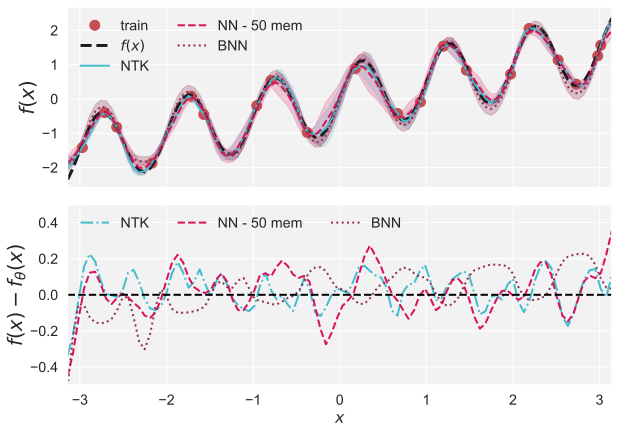

In [256]:
# residuals and pred plot
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True            # single shared x-axis
)

plt.sca(ax_top)

plot_fn(train, test)

# plt.plot(test_xs, nngp_mean, linestyle='-', color='#006BA6', linewidth=2, label='NNGP')
# plt.fill_between(
#     jnp.reshape(test_xs, (-1)),
#     nngp_mean - nngp_std,
#     nngp_mean + nngp_std,
#     color='#006BA6', alpha=0.2, label='_nolegend_')

plt.plot(test_xs, ntk_mean, linestyle='-', color='#43BCCD', linewidth=2, label='NTK')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    ntk_mean - ntk_std,
    ntk_mean + ntk_std,
    color='#43BCCD', alpha=0.2, label='_nolegend_')

phi_test = phi(test_xs)

# params is a tuple/list of pytrees: length = ensemble_size
ensemble_fx_50mem = jnp.stack(
    [apply_fn(p, phi_test).reshape(-1) for p in params_50mem],
    axis=0
)  # shape = (ensemble_size, n_test)
mean_fx_50mem = jnp.mean(ensemble_fx_50mem, axis=0)
std_fx_50mem  = jnp.std(ensemble_fx_50mem, axis=0)

plt.plot(test_xs, mean_fx_50mem, linestyle='--', color='#D81159', linewidth=2, label='NN - 50 mem')
plt.fill_between(
    jnp.reshape(test_xs, (-1)),
    mean_fx_50mem - std_fx_50mem,
    mean_fx_50mem + std_fx_50mem,
    color='#D81159', alpha=0.2, label='_nolegend_')
bnn_mean_np = np.asarray(bnn_mean_fn(test_xs)).ravel()
mu_np = np.asarray(mu).ravel()
sd_np = np.asarray(sd).ravel()
plt.plot(test_xs, bnn_mean_np, linestyle=':', color='#8F2D56', linewidth=2, label='BNN')
plt.fill_between(
    jnp.reshape(test_xs, (-1)), mu_np - sd_np, mu_np + sd_np,
    color='#8F2D56', alpha=0.25, label='_nolegend_'
)


plt.xlim([-jnp.pi, jnp.pi])
plt.legend(
    loc='upper left', frameon=False, ncol=2
)

plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_bay = np.array(test_ys).ravel() - bnn_mean_np.ravel()
residuals_ntk = np.array(test_ys).ravel() - ntk_mean.ravel()
residuals_net = np.array(test_ys).ravel() - mean_fx_50mem.ravel()

plt.plot(test_xs, residuals_ntk, linestyle='-.', color='#43BCCD', linewidth=2, label='NTK')
plt.plot(test_xs, residuals_net, linestyle='--', color='#D81159', linewidth=2, label='NN - 50 mem')
plt.plot(test_xs, residuals_bay, linestyle=':', color='#8F2D56', linewidth=2, label='BNN')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_{\theta}(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False, ncol=3)
plt.ylim([-0.5, 0.5])

plt.tight_layout()
plt.savefig("figs/BNN_NTK_NN50mem.pdf")
plt.show()
plt.close()